# Logistic Regression


### Overview

For each step, read the explanation, then **run the code cell(s)** right below it.

You will practice how to:

- Load and prepare data for a logistic regression model
- Compare **`statsmodels`** and **`sklearn`** logistic regression model objects
- Interpret **log(Odds) coefficients**, **odds ratios**, and **p-values**
- Diagnose multicollinearity using a **correlation matrix** and **VIF**
- Perform a simple coefficient-based variable elimination


#### Import libraries


In [1]:
import os
import sys
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, fbeta_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set random seed variable for code reproducibility
SEED = 1

In [2]:
# Import local libraries
root_dir = Path.cwd().resolve().parents[0]
sys.path.append(str(root_dir))

# Visualization functions
from src.visuals.make_plots import *

# Helper functions
from src.utils.helpers import *

# Load the "autoreload" extension so that code can change
%load_ext autoreload
#%reload_ext autoreload

# Always reload modules so that as you change code in src, it gets loaded
%autoreload 2

### Personal Loan Example

**Create a dataframe for the `UniversalBank.csv` data**

In the next cell, we:

* load the dataset,
* drop the `ID` and `ZIP Code` columns because they are not useful predictors,
* convert `Education` to a categorical variable with more readable labels, and
* create dummy variables for the education levels.

This is the Personal Loan Acceptance example in the lecture.


In [3]:

bank_df = pd.read_csv(os.path.join('..', 'data', 'UniversalBank.csv'))
bank_df.drop(columns=['ID', 'ZIP Code'], inplace=True)
bank_df.columns = [c.replace(' ', '_') for c in bank_df.columns]

bank_df['Education'] = bank_df['Education'].astype('category')
education_labels = {
    1: 'Undergrad',
    2: 'Graduate',
    3: 'Advanced/Professional'
}
bank_df['Education'] = bank_df['Education'].cat.rename_categories(education_labels)

bank_df = pd.get_dummies(bank_df, columns=['Education'], prefix='Education', drop_first=True, dtype=int)

bank_df.head()


,Age,Experience,Income,Family,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Education_Graduate,Education_Advanced/Professional
0,25,1,49,4,1.6,0,0,1,0,0,0,0,0
1,45,19,34,3,1.5,0,0,1,0,0,0,0,0
2,39,15,11,1,1.0,0,0,0,0,0,0,0,0
3,35,9,100,1,2.7,0,0,0,0,0,0,1,0
4,35,8,45,4,1.0,0,0,0,0,0,1,1,0


**Split the data into training and validation sets**

Next, we separate the predictors from the target variable `Personal_Loan`, then create a **training set (60%)** and a **validation set (40%)**.

We will use the training data to fit our models and the validation data to evaluate how well the model generalizes to new customers.


In [4]:

X = bank_df.drop(columns=['Personal_Loan'])
y = bank_df['Personal_Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=SEED)

print('Training Set:', X_train.shape)
print('Test Set:', X_test.shape)


Training Set: (3000, 12)
Test Set: (2000, 12)


**`statsmodels` vs. `sklearn` for Logistic Regression**

Both libraries can train logistic regression models, but they are usually used for **different goals**:

* **`statsmodels`** is often used when you want **inference and interpretation**, such as:
  * coefficient tables
  * standard errors
  * z-tests
  * p-values
  * confidence intervals
* **`sklearn`** is often used when you want **prediction and machine learning workflows**, such as:
  * model pipelines
  * cross-validation
  * regularization
  * automated model comparison
  * deployment-ready prediction tools

We will fit the same **single-predictor model using `Income`** with both libraries so we can compare the output.


**Fit a single-predictor logistic regression model with `statsmodels`**

For `statsmodels`, we must manually add a constant if we want an intercept term.  
Then we fit `Logit` and display the summary table.


In [5]:

X_train_income_sm = sm.add_constant( X_train[['Income']])
income_logit_sm = sm.Logit(y_train, X_train_income_sm).fit()

income_logit_sm.summary()


Optimization terminated successfully.
         Current function value: 0.201620
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          Personal_Loan   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2998
Method:                           MLE   Df Model:                            1
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.3609
Time:                        09:01:55   Log-Likelihood:                -604.86
converged:                       True   LL-Null:                       -946.37
Covariance Type:            nonrobust   LLR p-value:                1.474e-150
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.0627      0.237    -25.622      0.000      -6.526      -5.599
Income         0.0364      0.002     20.885      0.000       0.033       0.040
==============================================================================
"""

**Fit a single-predictor logistic regression model with `sklearn`**

For `sklearn`, the intercept is handled automatically when `fit_intercept=True` (the default).  
Unlike `statsmodels`, the model object focuses more on prediction attributes such as:

* `intercept_`
* `coef_`
* `predict()`
* `predict_proba()`

To make the coefficients more comparable to `statsmodels`, we set a very large `C` so the regularization effect is minimal.


In [6]:
params = {'penalty': 'l2', 'C': 1e42, 'solver': 'liblinear', 'random_state': SEED}
income_logit_sk = LogisticRegression(**params).fit(X_train[['Income']], y_train)

comparison_single = pd.DataFrame({
    'statsmodels': [income_logit_sm.params['const'], income_logit_sm.params['Income']],
    'sklearn': [income_logit_sk.intercept_[0], income_logit_sk.coef_[0][0]]
}, index=['Intercept', 'Income'])

comparison_single


,statsmodels,sklearn
Intercept,-6.062686,-6.048919
Income,0.036439,0.036343


### Key LogisticRegression Parameters

Below are a few important parameters for the `LogisticRegression` classifier that control regularization, model behavior, and optimization. Check the [API Reference](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) for the full list of parameters.

**penalty**
Specifies the type of regularization applied to the model.

* `"l2"` → Ridge regularization (default, most common)
* `"l1"` → Lasso regularization (can perform feature selection)
* `"elasticnet"` → Combination of L1 and L2
* `None` → No regularization

Regularization helps prevent overfitting by shrinking coefficients.

**C**
Inverse of regularization strength.

* Smaller values (e.g., `0.1`) → **Stronger regularization**
* Larger values (e.g., `10`) → **Weaker regularization**

Think of this as controlling how much we penalize large coefficients.

**solver**
Algorithm used to optimize the model.

* `"lbfgs"` → Default, good for most cases
* `"liblinear"` → Works well for small datasets and L1 penalty
* `"saga"` → Supports L1 and elastic net, good for large datasets
* `"newton-cg"` → Good for multinomial problems

Not all solvers support all penalties.

**max_iter**
Maximum number of iterations for the solver to converge.

* Default is `100`
* Increase if you see convergence warnings (e.g., `max_iter=1000`)

**fit_intercept**
Whether to include an intercept (constant term).

* `True` → Include intercept (recommended)
* `False` → No intercept

**class_weight**
Adjusts weights for classes (useful for imbalanced datasets).

* `None` → No weighting
* `"balanced"` → Automatically adjusts based on class frequencies

**multi_class**
Specifies how to handle multiclass problems.

* `"auto"` → Default (chooses best option)
* `"ovr"` → One-vs-Rest
* `"multinomial"` → Multinomial logistic regression

**l1_ratio** *(only used with elasticnet)*
Controls the mix between L1 and L2 regularization.

* `0` → Pure L2
* `1` → Pure L1
* Between 0 and 1 → Combination


**Calculate odds ratio**

In logistic regression, the coefficient is **not** the odds itself. The coefficient is the change in **log(odds)** for a one-unit increase in the predictor. You take `exp(coefficient)` to get the **odds ratio**.

So if the `Income` coefficient is positive, higher income increases the odds of accepting the personal loan offer.


In [7]:

coef_income = income_logit_sm.params['Income']
odds_income = np.exp(coef_income)

print(f"Income coefficient in log(odds): {coef_income:.4f}")
print(f"Income odds ratio: {odds_income:.4f}")


Income coefficient in log(odds): 0.0364
Income odds ratio: 1.0371


**Interpreting the `Income` odds ratio**

The odds ratio for `Income` is **1.0371**, which tells us how the odds of the target outcome change when Income increases. For every **1 unit increase in Income**, the **odds of the customer accepting the loan increase by about 3.71%**.


**Predict the probability for `Income = 140`**

Now we manually compute the predicted probability for a customer with income of **140 ($000s)** using the fitted `statsmodels` model.

We will calculate probability utilizing both the logistic function and using odds.


In [8]:
x = 140
log_odds = income_logit_sm.params['const'] + coef_income * x
print(f"log(Odds): {log_odds:.5f}")
p = 1 / (1 + np.exp(-log_odds))
print(f"Predicted probability for Income = ${x},000: {p:.5f}")

log(Odds): -0.96125
Predicted probability for Income = $140,000: 0.27663


In [9]:
odds = np.exp(log_odds)
print(f"Odds: {odds:.5f}")
p = odds / (1 + odds)
print(f"Predicted probability for Income = ${x},000: {p:.5f}")

Odds: 0.38242
Predicted probability for Income = $140,000: 0.27663


**Generate probability predictions for all customers using the single `Income` model**

Next, we compute predicted probabilities for every customer in the training set and inspect a few customers with `Income = 140`.

This lets us confirm that customers with the same predictor value receive the same predicted probability from this simple one-variable model.


In [10]:

train_income_preds = X_train[['Income']].copy()
train_income_preds['Prob'] = income_logit_sm.predict(X_train_income_sm)

train_income_preds[train_income_preds['Income'] == 140].head()


,Income,Prob
3193,140,0.276628
2776,140,0.276628
1696,140,0.276628
1931,140,0.276628
4354,140,0.276628


**Plot the logistic regression curve**

The scatterplot shows the observed target values (`0` or `1`) and the red line shows the predicted probability from the model.

This is a good visual reminder that logistic regression predicts a **probability between 0 and 1**, not a straight-line continuous outcome.


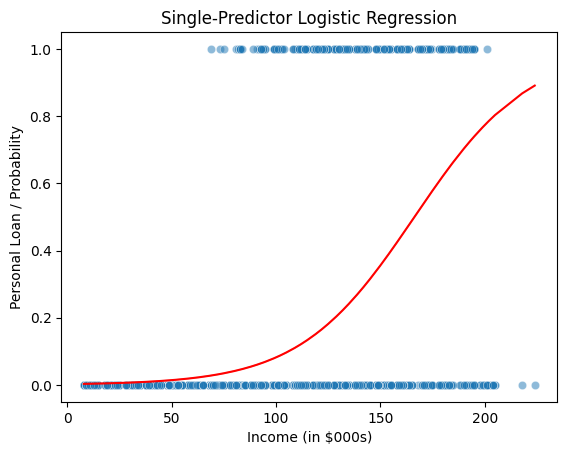

In [11]:

sns.scatterplot(x=train_income_preds['Income'], y=y_train, alpha=0.5)
sns.lineplot(x=train_income_preds['Income'], y=train_income_preds['Prob'], color='red')
plt.xlabel('Income (in $000s)')
plt.ylabel('Personal Loan / Probability')
plt.title('Single-Predictor Logistic Regression')
plt.show()


**Fit the full model with `statsmodels`**

Because `statsmodels` does not add the intercept automatically, we first add a constant column.


In [12]:

X_train_sm = sm.add_constant(X_train)

full_logit_sm = sm.Logit(y_train, X_train_sm).fit()

full_logit_sm.summary()


Optimization terminated successfully.
         Current function value: 0.113383
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          Personal_Loan   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2987
Method:                           MLE   Df Model:                           12
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.6406
Time:                        09:02:01   Log-Likelihood:                -340.15
converged:                       True   LL-Null:                       -946.37
Covariance Type:            nonrobust   LLR p-value:                3.627e-252
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                             -12.5634      2.336     -5.377      0.000     -17.143      -7.984
Age                                -0.0354      0.086     -0.412      0.680      -0.204       0.133
Experience                          0.0369      0.086      0.431      0.666      -0.131       0.205
Income                              0.0589      0.004     15.044      0.000       0.051       0.067
Family                              0.6128      0.103      5.931      0.000       0.410       0.815
CCAvg                               0.2408      0.060      4.032      0.000       0.124       0.358
Mortgage                            0.0010      0.001      1.301      0.193      -0.001       0.003
Securities_Account                 -1.0305      0.422     -2.443      0.015      -1.857      -0.204
CD_Account                          3.6628      0.460      7.961      0.000       2.761       4.565
Online                             -0.6794      0.216     -3.140      0.002      -1.103      -0.255
CreditCard                         -0.9609      0.274     -3.507      0.000      -1.498      -0.424
Education_Graduate                  4.2075      0.364     11.573      0.000       3.495       4.920
Education_Advanced/Professional     4.3580      0.365     11.937      0.000       3.642       5.074
===================================================================================================

Possibly complete quasi-separation: A fraction 0.12 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

### p-Values in Logistic Regression

**With `statsmodels`**: p-values are built into the regression summary and also available directly from `.pvalues`.  
**With `sklearn`**: p-values are **not returned** by the model object.

A common practical approach is:

1. fit the predictive model in `sklearn`, and
2. fit the same design matrix in `statsmodels` when you need inference statistics such as p-values.

So in practice, `sklearn` does **not** calculate p-values for you directly so is one practical advantage of using `statsmodel`.


**Extract p-values from the `statsmodels` model**

Below we create a table showing each predictor's coefficient, odds ratio, and p-value.


In [13]:

pvalue_table = pd.DataFrame({
    'coefficient': full_logit_sm.params,
    'odds_ratio': np.exp(full_logit_sm.params),
    'p_value': full_logit_sm.pvalues
}).sort_values('p_value')

pvalue_table


,coefficient,odds_ratio,p_value
Income,0.058903,1.060673,3.779285e-51
Education_Advanced/Professional,4.358011,78.101644,7.557217e-33
Education_Graduate,4.207538,67.190886,5.663682e-31
CD_Account,3.662765,38.968928,1.704376e-15
Family,0.612780,1.845555,3.013497e-09
const,-12.563415,0.000003,7.569821e-08
CCAvg,0.240769,1.272227,5.534312e-05
CreditCard,-0.960866,0.382562,4.533950e-04
Online,-0.679423,0.506909,1.686926e-03
Securities_Account,-1.030544,0.356813,1.455230e-02


### Multicollinearity: Correlation Matrix and VIF

Multicollinearity happens when predictors carry overlapping information. This can make coefficient estimates unstable and harder to interpret.

Two common tools are:

- **Correlation matrix**: helps identify pairs of numeric variables that move closely together.
- **VIF (Variance Inflation Factor)**: measures how strongly one predictor is explained by the other predictors.

A common rough guideline is:

- **VIF near 1** → little multicollinearity
- **VIF above 5** → possible concern
- **VIF above 10** → strong concern


**Create a correlation matrix for all predictors**

This heatmap helps us visually spot strong positive or negative linear relationships.


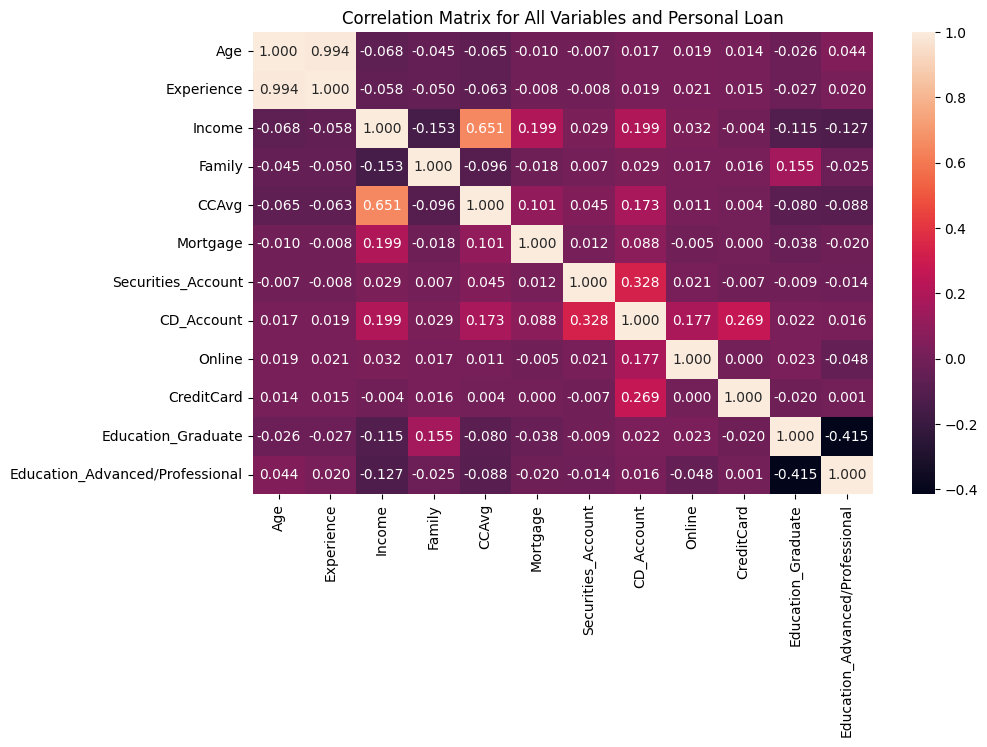

In [14]:
bank_corr = X_train.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(bank_corr, annot=True, fmt='.3f', ax=ax)
plt.title('Correlation Matrix for All Variables and Personal Loan')
plt.show()


**Calculate VIF values**

Unlike the correlation matrix, VIF looks at each predictor in relation to **all of the other predictors together**.

This means VIF can detect multicollinearity patterns that are not obvious from only looking at pairwise correlations.


In [15]:

vif_X = sm.add_constant(X_train)

vif_table = pd.DataFrame({
    'variable': vif_X.columns,
    'VIF': [variance_inflation_factor(vif_X.values, i) 
            for i in range(vif_X.shape[1])]
})

# Remove the constant row
vif_table = vif_table[vif_table['variable'] != 'const'] \
    .sort_values('VIF', ascending=False)

vif_table

,variable,VIF
1,Age,93.458887
2,Experience,93.380832
3,Income,1.903752
5,CCAvg,1.752490
12,Education_Advanced/Professional,1.354896
8,CD_Account,1.352328
11,Education_Graduate,1.302776
7,Securities_Account,1.141582
10,CreditCard,1.101042
4,Family,1.052286


**Interpret the multicollinearity results**

A variable pair such as `Age` and `Experience` is often a good example of multicollinearity because those two measures can be highly related.

If a variable has a high VIF, it does **not automatically mean** you must remove it.  
Instead, it means you should pause and think about:

- whether the variables are redundant,
- whether the coefficients are unstable,
- whether interpretation matters more than prediction, and
- whether you should remove, combine, or transform predictors.


**Inspect smallest absolute log(Odds) coefficients**

A very basic heuristic is to look for the predictor with the **smallest absolute coefficient** in the fitted logistic regression model.

Why this can be useful:

- a coefficient close to `0` means the predictor has little impact on the **log(odds)**,
- it gives a quick first-pass screening idea.

Why you should be cautious:

- coefficient size depends on the variable's scale,
- multicollinearity can distort coefficients,
- a small coefficient does **not** always mean the variable is unimportant.

So this is a simple teaching example, not a full model-selection strategy.


**Find the predictor with the smallest absolute coefficient**

We exclude the intercept and sort the coefficients by their absolute size.


In [16]:

coef_screen = pd.DataFrame({
    'coefficient': full_logit_sm.params.drop('const')
})
coef_screen['abs_coefficient'] = coef_screen['coefficient'].abs()
coef_screen = coef_screen.sort_values('abs_coefficient')

coef_screen


,coefficient,abs_coefficient
Mortgage,0.001014,0.001014
Age,-0.035385,0.035385
Experience,0.036941,0.036941
Income,0.058903,0.058903
CCAvg,0.240769,0.240769
Family,0.612780,0.612780
Online,-0.679423,0.679423
CreditCard,-0.960866,0.960866
Securities_Account,-1.030544,1.030544
CD_Account,3.662765,3.662765


**Remove variables and refit the model**

In this step, we will remove two variables from the final model:

* `Age` - Highest VIF multicollinearity with `Experience`
* `Mortgage` - Low absolute impact on log(Odds)

In this step, we will use sklearn to train the updated model.


In [17]:
drop_cols = ['Age', 'Mortgage']
reduced_predictors = [col for col in X_train.columns if col not in drop_cols]

reduced_logit_sk = LogisticRegression(**params).fit(X_train[reduced_predictors], y_train)

reduced_logit_sk

LogisticRegression(C=1e+42, random_state=1, solver='liblinear')

**Create a confusion matrix for full model**

Now, let's visualize the confusion matrix using the test partition.

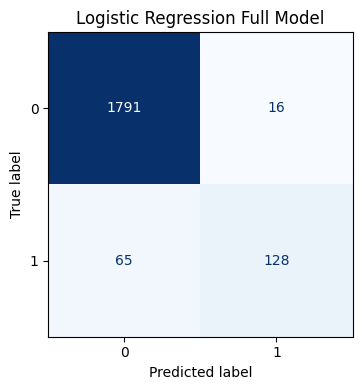

In [18]:
fig, ax = plt.subplots(figsize=(4, 4))
title1 = 'Logistic Regression Full Model'
plot_confusion_matrix(reduced_logit_sk, X_test[reduced_predictors], y_test, ax, 'Logistic Regression Full Model')

**Display evaluation metrics for full model**

Create predictions and display the evaluation metrics for the full model.

In [19]:
pred1 = reduced_logit_sk.predict(X_test[reduced_predictors])

logit_sk_metrics = evaluate_model(y_test, pred1, beta=2, model_name=title1)
logit_sk_metrics

,Accuracy,Precision,Recall,F1,F2
Logistic Regression Full Model,0.9595,0.888889,0.663212,0.759644,0.69869
